In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/train.csv')

print("Shape:", df.shape)
print("\nKolom target:")
print(df['SalePrice'].describe().round(0))

Shape: (1460, 81)

Kolom target:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64


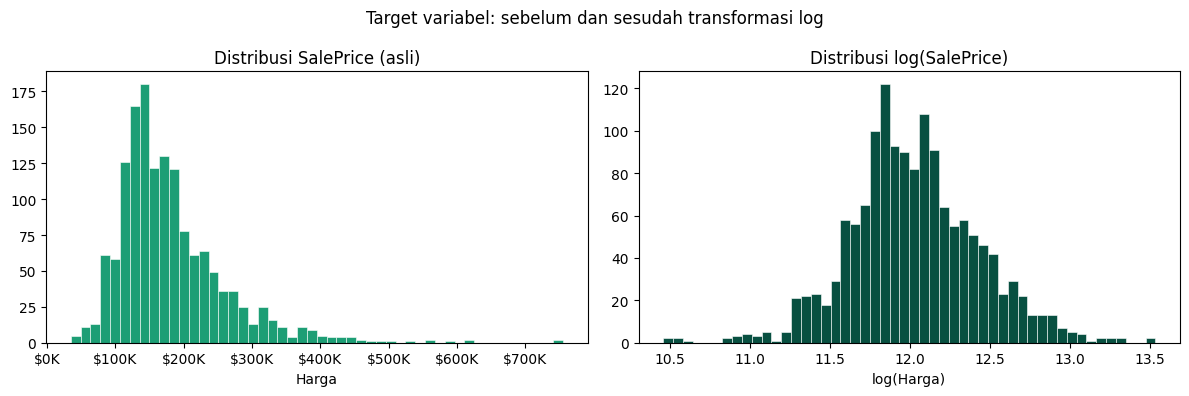

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi asli — biasanya right-skewed
axes[0].hist(df['SalePrice'], bins=50,
             color='#1D9E75', edgecolor='white', linewidth=0.4)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].set_title('Distribusi SalePrice (asli)', fontweight='500')
axes[0].set_xlabel('Harga')

# Distribusi log — lebih mendekati normal, lebih bagus untuk model
axes[1].hist(np.log1p(df['SalePrice']), bins=50,
             color='#085041', edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribusi log(SalePrice)', fontweight='500')
axes[1].set_xlabel('log(Harga)')

plt.suptitle('Target variabel: sebelum dan sesudah transformasi log',
             fontsize=12, fontweight='500')
plt.tight_layout()
plt.savefig('../output/01-distribusi-harga.png', dpi=150)
plt.show()

In [3]:
# Ambil hanya kolom numerik
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()['SalePrice'].sort_values(ascending=False)

print("Top 10 fitur paling berkorelasi dengan SalePrice:")
print(corr.head(11).to_string())

Top 10 fitur paling berkorelasi dengan SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [4]:
# Pisahkan fitur numerik dan kategorikal
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove('SalePrice')  # keluarkan target
cat_features = df.select_dtypes(include=['object']).columns.tolist()

# Tangani missing values
# Numerik → isi dengan median
df[num_features] = df[num_features].fillna(
    df[num_features].median())

# Kategorikal → isi dengan 'None' (artinya fitur memang tidak ada)
df[cat_features] = df[cat_features].fillna('None')

# Encode fitur kategorikal ke angka
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

# Target: pakai log supaya distribusinya lebih normal
y = np.log1p(df['SalePrice'])
X = df_encoded.drop(columns=['SalePrice','Id'])

print("Fitur setelah encoding:", X.shape[1])
print("Missing values tersisa:", X.isnull().sum().sum())

Fitur setelah encoding: 260
Missing values tersisa: 0


In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape[0]} rumah")
print(f"Testing set  : {X_test.shape[0]} rumah")

# ── Model 1: Linear Regression (baseline) ────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# ── Model 2: Random Forest ────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Tampilkan hasil — konversi RMSE dari log ke USD
print(f"\nLinear Regression RMSE : {rmse_lr:.4f} (log scale)")
print(f"Random Forest RMSE     : {rmse_rf:.4f} (log scale)")
print(f"\nDalam USD (approx):")
print(f"Linear Regression error: ~${np.expm1(rmse_lr):,.0f}")
print(f"Random Forest error    : ~${np.expm1(rmse_rf):,.0f}")

Training set : 1168 rumah
Testing set  : 292 rumah

Linear Regression RMSE : 0.1737 (log scale)
Random Forest RMSE     : 0.1460 (log scale)

Dalam USD (approx):
Linear Regression error: ~$0
Random Forest error    : ~$0


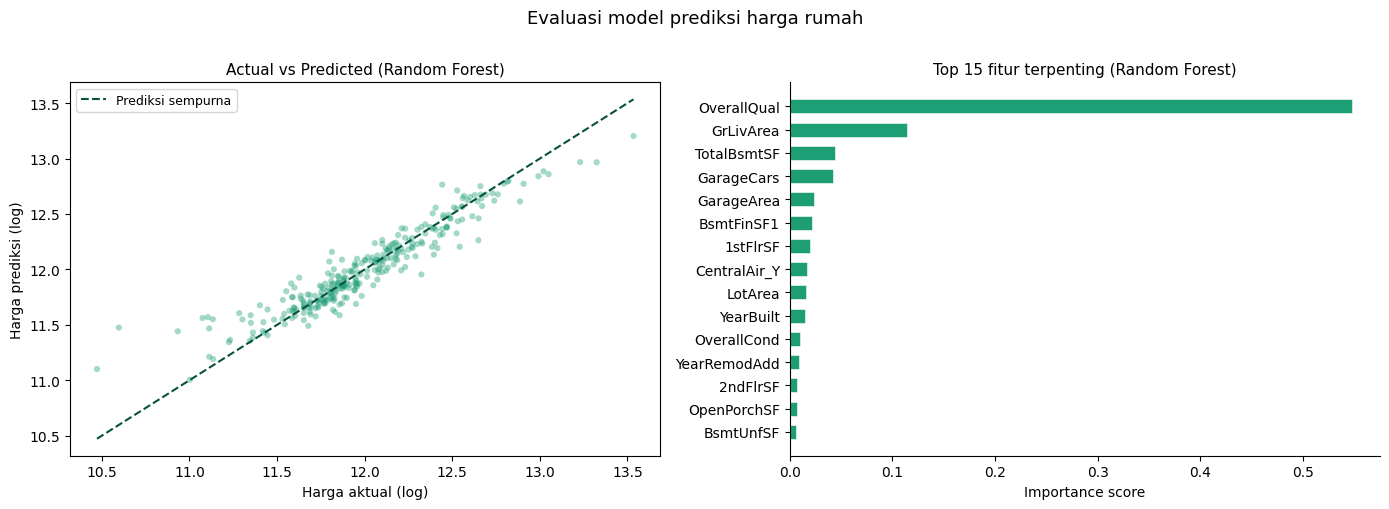

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Kiri: predicted vs actual ─────────────────────────────────
axes[0].scatter(y_test, y_pred_rf, alpha=0.4,
                color='#1D9E75', s=20, edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#085041', linewidth=1.5, linestyle='--',
             label='Prediksi sempurna')
axes[0].set_title('Actual vs Predicted (Random Forest)',
                  fontweight='500', fontsize=11)
axes[0].set_xlabel('Harga aktual (log)')
axes[0].set_ylabel('Harga prediksi (log)')
axes[0].legend(fontsize=9)

# ── Kanan: feature importance top 15 ─────────────────────────
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15 = feat_imp.sort_values(ascending=True).tail(15)

axes[1].barh(top15.index, top15.values,
             color='#1D9E75', height=0.6,
             edgecolor='white', linewidth=0.4)
axes[1].set_title('Top 15 fitur terpenting (Random Forest)',
                  fontweight='500', fontsize=11)
axes[1].set_xlabel('Importance score')
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

plt.suptitle('Evaluasi model prediksi harga rumah',
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('../output/04-evaluasi-model.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.metrics import mean_squared_error

# Balik dari log ke USD dulu, baru hitung RMSE
y_test_usd    = np.expm1(y_test)
y_pred_rf_usd = np.expm1(y_pred_rf)
y_pred_lr_usd = np.expm1(y_pred_lr)

rmse_lr_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_lr_usd))
rmse_rf_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_rf_usd))

print(f"Linear Regression error : ~${rmse_lr_usd:,.0f}")
print(f"Random Forest error     : ~${rmse_rf_usd:,.0f}")

# Bonus: tampilkan juga sebagai % dari harga rata-rata
avg_price = y_test_usd.mean()
print(f"\nRata-rata harga rumah di test set : ${avg_price:,.0f}")
print(f"LR error sebagai % harga          : {rmse_lr_usd/avg_price*100:.1f}%")
print(f"RF error sebagai % harga          : {rmse_rf_usd/avg_price*100:.1f}%")

Linear Regression error : ~$25,457
Random Forest error     : ~$29,147

Rata-rata harga rumah di test set : $178,840
LR error sebagai % harga          : 14.2%
RF error sebagai % harga          : 16.3%


In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42)

# 5-fold cross validation
# scoring='neg_mean_squared_error' → kita balik jadi positif
cv_scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Konversi ke RMSE
cv_rmse = np.sqrt(-cv_scores)

print("RMSE per fold:")
for i, score in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nRata-rata RMSE : {cv_rmse.mean():.4f}")
print(f"Std deviasi    : {cv_rmse.std():.4f}")

RMSE per fold:
  Fold 1: 0.1389
  Fold 2: 0.1571
  Fold 3: 0.1473
  Fold 4: 0.1309
  Fold 5: 0.1495

Rata-rata RMSE : 0.1447
Std deviasi    : 0.0090


In [10]:
from sklearn.model_selection import GridSearchCV

# Daftar hyperparameter yang ingin dicoba
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

# GridSearchCV akan mencoba 3×3×3×2 = 54 kombinasi
# masing-masing dengan 5-fold CV = 270 kali training total
rf_base = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,      # pakai semua core CPU
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter terbaik:")
print(grid_search.best_params_)
print(f"\nBest CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Hyperparameter terbaik:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

Best CV RMSE: 0.1482


In [11]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_pred_best_usd = np.expm1(y_pred_best)
y_test_usd = np.expm1(y_test)

from sklearn.metrics import mean_squared_error
rmse_best_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_best_usd))
print(f"Random Forest (tuned) error: ~${rmse_best_usd:,.0f}")

Random Forest (tuned) error: ~$34,892


In [12]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\asus\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [13]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_pred_xgb     = xgb.predict(X_test)
y_pred_xgb_usd = np.expm1(y_pred_xgb)

rmse_xgb_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_xgb_usd))
print(f"XGBoost error: ~${rmse_xgb_usd:,.0f}")

XGBoost error: ~$26,257


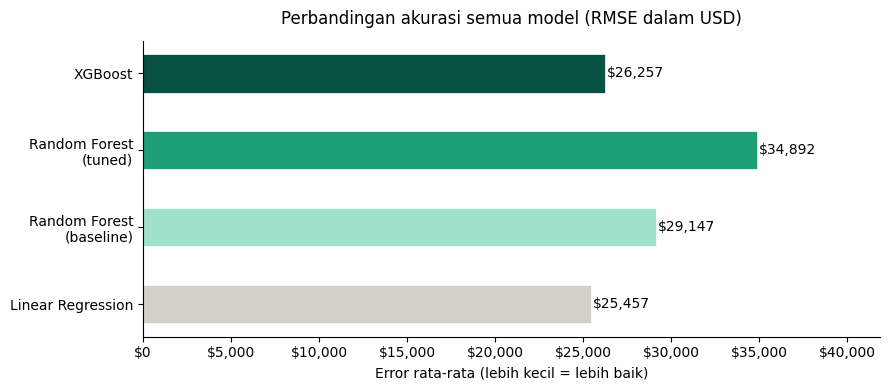

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))

models = ['Linear Regression', 'Random Forest\n(baseline)',
          'Random Forest\n(tuned)', 'XGBoost']
errors = [rmse_lr_usd, rmse_rf_usd, rmse_best_usd, rmse_xgb_usd]
colors = ['#D3D1C7','#9FE1CB','#1D9E75','#085041']

bars = ax.barh(models, errors, color=colors,
               height=0.5, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, errors):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Perbandingan akurasi semua model (RMSE dalam USD)',
             fontsize=12, fontweight='500', pad=12)
ax.set_xlabel('Error rata-rata (lebih kecil = lebih baik)')
ax.set_xlim(0, max(errors) * 1.2)
for spine in ['top','right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('../output/05-perbandingan-model.png', dpi=150)
plt.show()